# 11 Back-EMF over-read on rev 2A

Notebook 08 left one thing open about the firmware's model back-EMF. On board D, at low duty,
it reads fast. On the SG90 2S grid it was +13% at 15% duty, +6.6% at 20% and +0.9% at 30%, linear
in duty between 15 and 35% and gone above that. The suspect at the time was board D's terminal
chain, which was a bodge on the way to rev 2A. The policy was to score the same thing again on
rev 2A before touching any firmware.

This notebook is that re-score. It runs on the MG90 session captured on rev 2A board #1, and
puts board D's MG90 session under the same current limit next to it as the control, so the
motor is the same on both sides. Then it scores two candidate causes, and checks whether either
one explains the verify run reading the velocity loop 3.4 to 4.7% slow.

It is a new notebook rather than a section of notebook 08 because notebook 08 is built around
sg90-a on board D. Its constants, its ripple helpers and its rung iterator are all bound to that
servo and to the classic grid layout, and these captures are MG90 session recordings under the
current limit. Bolting them on would mean re-running all of notebook 08 for a section about a
different servo.

If you only want the short version:

- On rev 2A the over-read is about a third of board D's, on the same motor. Against a $K_e$ fitted
  on the 25 and 30% rungs, the 15% rung reads 3.0 to 3.6% high on 2A and 7.7 to 7.8% high on
  board D. The part that does not scale with speed is +34 to +49 mV on 2A and +118 to +125 mV on
  board D.
- The terminal chain is not it. Both boards read the open circuit EMF of a coast the same, 1.24
  mV per ripple Hz on 2A against 1.21 to 1.23 on board D.
- Candidate (a), the drive pulse coming out shorter than commanded, explains all of 2A's
  over-read with a pulse 11 to 16 timer ticks short. That is the 10 to 15 ticks the bench puts
  on this motor at its 0.1 A, not the 20 to 30 of the resistor grid, and 20 to 30 ticks
  over-corrects. Candidate (b), the OFF window weighted at the brake drop, is the right sign and
  worth about 16 mV, a third to a half of what is there.
- Neither explains verify. Every verify leg runs at 8 to 11% duty, under the 160 tick voltage
  floor, so the loop never saw the back-EMF there. And even if it had, the model's over-read
  shrinks with speed, where verify's grows.

## Picking a rig

The rev 2A session is the dataset under test. Board D's session of the same servo under the same
current limit, `mg90-a__2s__limit`, rides along as the control: same motor, same gears, same drive
rule, a different board.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import oscnb
from oscnb import governed, poslut, ripple, session

ds = oscnb.use("mg90-a__dev-v006-2A__2s__limit")
board, servo = oscnb.current().board, oscnb.current().servo
ds_d = oscnb.datasets.load("mg90-a__2s__limit")          # board D, same servo, same rule
SETS = {"rev 2A": ds, "board D": ds_d}

FS = board.tick_hz
DT = 1.0 / FS
Q15 = 32767
ARR = board.pwm_half_ticks                               # timer ticks per half period, D = drive_ticks / ARR
V_FLOOR = board.floor_v_ticks                            # the build's v_window_min_ticks, 160
R_REG = servo.measured["r_winding_measured"]              # 4.89 [4.49, 4.98] ohm, terminal referenced

# What the servo carried for the verify run that followed the session: R from the plant block
# every recording carries (r_q12 4608, the stored 5.02 ohm the identification kept), and Ke from
# that identification's ladder, 26 to 64% duty against timed pot speed with the 0xdc96 table live.
FW_R_VPC = ds.recordings("session", "capture-1")[0].meta["drive"]["r_q12"] / 4096
FW_KE_VPC = 0.09066                                       # vcounts per linearized count per second
FW_R_OHM = FW_R_VPC * board.v_term_per_count / board.a_per_count

# The crest scan closes tap A 83 ticks and tap B 135 ticks after the counter peak (nb10 sec 8),
# and the chopping terminal is A forward, B reverse. A rung's crest volts are honest only when
# its half window outlasts that slot plus the ~9 tick turn-off lag.
TAP_SLOT = {1: 83, -1: 135}
TURN_OFF = 9

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
print(f"firmware R {FW_R_VPC:.4f} vcounts per ccount = {FW_R_OHM:.3f} ohm, Ke {FW_KE_VPC} vcounts per c/s")

dataset  mg90-a__dev-v006-2A__2s__limit
supply   2s
rig      Vorpal MG90 clone, unit A on osc-dev-v006 rev 2A, board #1



,captures,recordings per capture,names
experiment,,,
session,5,2,"fast, slow"



derived constants (what the hardware is)


value
where            quantity                                           unit                          
board            converter step                                     mV per count            0.8057
                 terminal divider ratio r                                                   5.0000
                 terminal difference                                mV per count            4.0283
                 terminal bias VB                                   mV                    622.6415
                                                                    counts                772.8302
                 driven-low terminal reads                          counts                618.2642
                 motor current                                      mA per count            0.9022
                                                                    counts per A         1108.4521
                 shunt                                              mOhm                   60.0000
                 amplifier gain                                     x                      14.8840
                 rail tap ratio                                                             5.0000
                 sample rate                                        samples per ms         20.0000
                 current settled from (UNVERIFIED)                  % duty                 13.3333
                 voltage settled from (UNVERIFIED)                  % duty                 13.3333
servo            pot intercept                                      counts                209.0000
                 pot slope                                          counts per degree      19.7600
                 envelope low                                       counts (15.74 deg)    520.0224
                 envelope high                                      counts (168.59 deg)  3540.3384
                 runway                                             counts               3020.3160
                 seek guard low                                     counts                520.0000
                 seek guard high                                    counts               3540.0000
servo (measured) gear_ratio_measured [308.053, 308.053] mechanic... :1                    308.0533
                 ripple_order_measured [6, 6] teardown, 3-slot b... per motor rev           6.0000
                 r_winding_measured [4.49, 4.98] bringup capture... Ohm                     4.8900
                 ke_ripple_measured [1.284, 1.306] nb09 sec 3, s... mV per ripple Hz        1.2950
                 pot_scale_measured [19.7, 19.85] nb09 sec 10, r... counts/deg             19.7600
                 travel_measured [178.67, 189.18] nb09 sec 10, p... deg                   184.2200
                 low_stop_after_stall_measured [232, 236] hand s... counts                232.0000
                 backlash_measured [1.25, 1.5] nb09 sec 4, rever... ripple cycles           1.4800


measured values (what someone found when they looked)


value  \
where quantity                           
board rest_current_noise      1.280000   
      crest_floor             7.000000   
      shunt_settle          156.000000   
      current_chain_scale     0.500000   
servo gear_ratio            308.053333   
      ripple_order            6.000000   
      r_winding               4.890000   
      ke_ripple               1.295000   
      pot_scale              19.760000   
      travel                184.220000   
      low_stop_after_stall  232.000000   
      backlash                1.480000   

                                                                        unit  \
where quantity                                                                 
board rest_current_noise                                          counts RMS   
      crest_floor                                               % duty on 2S   
      shunt_settle          ticks from the ON compare to 1% of the 100% rung   
      current_chain_scale                                 % high vs Rs1 pads   
servo gear_ratio                                                          :1   
      ripple_order                                             per motor rev   
      r_winding                                                          Ohm   
      ke_ripple                                             mV per ripple Hz   
      pot_scale                                                   counts/deg   
      travel                                                             deg   
      low_stop_after_stall                                            counts   
      backlash                                                 ripple cycles   

                                       bracket  \
where quantity                                   
board rest_current_noise          [1.22, 1.33]   
      crest_floor                      [7, 10]   
      shunt_settle                  [150, 156]   
      current_chain_scale          [-0.7, 2.3]   
servo gear_ratio            [308.053, 308.053]   
      ripple_order                      [6, 6]   
      r_winding                   [4.49, 4.98]   
      ke_ripple                 [1.284, 1.306]   
      pot_scale                  [19.7, 19.85]   
      travel                  [178.67, 189.18]   
      low_stop_after_stall          [232, 236]   
      backlash                     [1.25, 1.5]   

                                                                       source  \
where quantity                                                                  
board rest_current_noise            nb10 sec 3, grid 2S ladder rest baselines   
      crest_floor               nb10 sec 5 and 8, static-load ladder + bursts   
      shunt_settle          nb10 sec 8, 2S grid bursts folded at 4 ticks, ...   
      current_chain_scale            Rs1 pads mV during a 4.2 s 100% grid lap   
servo gear_ratio                              mechanical/mg90/measurements.py   
      ripple_order                             teardown, 3-slot brushed motor   
      r_winding             bringup captures/mg90/plant.py, onset regressi...   
      ke_ripple             nb09 sec 3, settled windows of the 15-50% grid...   
      pot_scale             nb09 sec 10, ripple cycles stitched over the c...   
      travel                nb09 sec 10, phys stop to phys stop 209..3849:...   
      low_stop_after_stall  hand stop, firm push, 2026-09-28, after the st...   
      backlash              nb09 sec 4, reversal blocks, commutation steps...   

                                                                       caveat  
where quantity                                                                 
board rest_current_noise    the whole chain at rest with the bridge off, o...  
      crest_floor           honest to 3% from 7%, and the 7% edge is tap A...  
      shunt_settle          3.25 us. The current is half way 44 ticks afte...  
      current_chain_scale   meter 93-94 mV across Rs1 against 93.3-95.1 mV...  
servo g

firmware R 1.1250 vcounts per ccount = 5.023 ohm, Ke 0.09066 vcounts per c/s


## 1. The reference

The speed reference is the commutation ripple, counted with `oscnb.ripple.motor_angle` the
way notebook 09 does it. The pot only seeds the tracker's search band, it never becomes a speed.
Each grid rung is scored over its settled window from `oscnb.governed`, which waits for the
applied duty to reach the goal under the current limit. A rung counts when the tracker holds
the line through the whole settled window and its coupling, ripple cycles per pot count, sits
within 3% of the set's median, which rejects a lock on the f/2 or f/3 family.

The tracker's frequency floor comes down from 250 to 200 Hz here. On 2A the 10% rungs run near
275 Hz with a wobble of several percent once per revolution, so at 250 the ridge drops out on
the slow part of a revolution. The line itself is 30 times the noise floor there.

The current is read against the in-drive zero, the brake trough sample of the same rung. That
is the zero the firmware's bias tracker learns. It sits 10 counts over the torque-off rest on
2A and 6 on board D, because the DRV8212P's own supply current returns through the shunt once
the driver is awake. Section 3 shows what the other zero does.

In [2]:
def frames(d):
    for c in d.captures("session"):
        df, meta = session.read(d, c, "grid")
        yield c, df, meta


def coupling_prior(d):
    # ripple cycles per raw count over settled 20-30% rungs, only to seed the tracker band
    out = []
    for cap, df, meta in frames(d):
        bias = df[df.seg == 0].current_raw.mean()
        for seg, g in df[df.seg > 0].groupby("seg"):
            if not 20 <= abs(g.cmd_duty_q15.iloc[0] * 100 / Q15) <= 30:
                continue
            st = governed.settled(g, FS)
            f, X = ripple.line_spectrum(st.current_raw.to_numpy() - bias, FS)
            out.append(ripple.settled_line(f, X)[0] / abs(ripple.pot_speed(st, FS, 1.0)))
    return float(np.median(out))


def track(d, label):
    b = d.board
    built = d.path / "pos-lut-built.json"
    table = json.loads(built.read_text()) if built.exists() else d.pos_lut
    lut = poslut.GridLut.from_json(json.dumps(table))   # linearized counts, for the c/s scale
    cp = coupling_prior(d)
    rows = []
    for cap, df, meta in frames(d):
        rest = df[df.seg == 0].current_raw.mean()
        df = df.assign(bias=rest)
        for seg, g in df[df.seg > 0].groupby("seg"):
            duty = int(round(g.cmd_duty_q15.iloc[0] * 100 / Q15))
            sg = int(np.sign(duty))
            if abs(duty) < 10:
                continue
            s0 = governed.settled_from(g, FS)
            cyc, n0, _ = ripple.motor_angle(g, cp, FS, 1.0, f_floor=200.0)
            row = dict(set=label, cap=cap, duty=duty, dir=sg, tracked=cyc is not None and s0 is not None and n0 <= s0)
            if row["tracked"]:
                s = g.iloc[s0:]
                k = np.arange(s0, len(g))
                h = np.abs(s.duty_q15.to_numpy()).mean() * ARR / Q15
                row.update(
                    f=(cyc[-1] - cyc[s0]) / ((len(g) - 1 - s0) * DT),                 # ripple Hz, counted
                    cpc=np.polyfit(lut.counts(g.pos.to_numpy()[k]) * sg, cyc[k], 1)[0],  # cycles per linearized count
                    D=h / ARR, ticks=h, v_ok=h >= TAP_SLOT[sg] + TURN_OFF,
                    vd=((s.vmotor_a - s.vmotor_b).to_numpy() * sg).mean(),           # crest terminal difference, vcounts
                    i=(s.current_raw - s.current_trough).mean(),                     # in-drive zero, ccounts
                    i_rest=(s.current_raw - rest).mean(),                            # torque-off zero, ccounts
                    rail=b.vsys_v(s.vbus_raw).mean() if s.vbus_raw.notna().any() else np.nan)
            rows.append(row)
    t = pd.DataFrame(rows)
    med = t[t.tracked & t.duty.abs().between(15, 30)].cpc.median()
    t["ok"] = t.tracked & ((t.cpc / med - 1).abs() < 0.03)
    t["V_on"] = t.vd * b.v_term_per_count
    t["i_A"] = t.i * b.a_per_count
    t["i_rest_A"] = t.i_rest * b.a_per_count
    return t


G = pd.concat([track(d, k) for k, d in SETS.items()], ignore_index=True)
# both boards over the duties both grids ran
G = G[G.duty.abs() <= 30]
display(G.groupby(["set", "duty"]).agg(
    rungs=("cap", "size"), accepted=("ok", "sum"), volts_honest=("v_ok", "all"),
    ripple_Hz=("f", "mean"), V_on=("V_on", "mean"), i_mA=("i_A", lambda s: s.mean() * 1e3),
    cycles_per_count=("cpc", "median")).round(3).unstack(0))

rungs        accepted        volts_honest        ripple_Hz              V_on           i_mA         cycles_per_count       
set  board D rev 2A  board D rev 2A      board D rev 2A   board D    rev 2A board D rev 2A board D  rev 2A          board D rev 2A
duty                                                                                                                              
-30        5      5        5      5         True   True  1449.827  1275.709   7.784  7.377  63.222  99.023            0.264  0.270
-25        5      5        5      5         True   True  1176.698  1025.318   7.789  7.382  56.695  90.782            0.263  0.270
-20        5      5        5      5         True   True   888.512   772.474   7.792  7.389  53.994  83.645            0.264  0.269
-15        5      5        5      5         True   True   601.015   514.990   7.794  7.395  53.007  78.496            0.263  0.269
-10        5      5        5      1        False  False   326.325   272.102   6.989  6.182  50.613  75.779            0.261  0.269
 10        5      5        5      5         True   True   344.575   275.108   7.803  7.415  43.961  72.157            0.266  0.269
 15        5      5        5      5         True   True   619.732   516.787   7.791  7.393  52.823  82.229            0.263  0.269
 20        5      5        5      5         True   True   904.669   775.362   7.787  7.385  59.464  89.354            0.263  0.268
 25        5      5        5      5         True   True  1188.212  1039.738   7.782  7.381  64.691  94.372            0.263  0.268
 30        5      5        5      5         True   True  1469.790  1301.832   7.778  7.378  69.038  99.502            0.263  0.268

**What you are looking at.** One row per duty, the two boards side by side. `accepted` is how
many of the five captures' rungs the tracker held, `volts_honest` whether the crest terminal
sample lands inside the drive window, `ripple_Hz` the counted line over the settled window,
`V_on` the crest terminal difference in volts and `i_mA` the in-drive current.

Every 15 to 30% rung on both boards tracks. The 10% forward rungs track and their tap A sample
is honest. Tap B samples after the window has closed, so the 10% reverse rungs have no honest
volts whether they track or not, and they leave every table below.

The two boards do not run the motor the same. On 2A the rail is 7.38 V at the terminals against
7.79 V on board D, and the motor draws 78 to 100 mA where it drew 53 to 69 on board D, so the
same duty turns it 11 to 17% slower. The two sessions are two days and a lot of running apart,
on a gear train that has been through stalls. Everything below is per board, so this only
matters where a number depends on speed or current.

## 2. The firmware model as it stands

The firmware computes $\hat\omega = (D\,v_{on} - R\,i)/K_e$ in counts, with $D\,v_{on}$ the drive
ticks over ARR times the crest terminal difference. This is notebook 08's "firmware, registry R
and Ke" row, scored on 2A with the constants the servo carried when it ran verify. The reference
goes into the same linearized counts per second through the measured coupling of the 0xdc96
table, ripple cycles per linearized count, so no pot speed enters.

In [3]:
A = G[(G.set == "rev 2A") & G.ok & G.v_ok].copy()
CPC = A.cpc.median()                                       # ripple cycles per linearized count, 0xdc96 table
A["w"] = A.f / CPC                                         # reference speed, linearized c/s
A["est"] = (A.D * A.vd - FW_R_VPC * A.i) / FW_KE_VPC
A["ratio"] = A.est / A.w
fw = A.pivot_table(index="duty", columns="cap", values="ratio")
fw["mean"] = fw.mean(axis=1)
fw["reference c/s"] = A.groupby("duty").w.mean()
NB08_2S = {15: 1.130, 20: 1.066, 25: 1.032, 30: 1.009}       # nb08 sec "The intercept", sg90-a on board D, 2S
fw["nb08, sg90-a on board D"] = [NB08_2S.get(abs(k), np.nan) for k in fw.index]
print(f"{CPC:.4f} ripple cycles per linearized count (spread {A.cpc.min():.4f} .. {A.cpc.max():.4f})")
print("estimate over reference, firmware R and Ke, per capture")
display(fw.round(3))

0.2686 ripple cycles per linearized count (spread 0.2679 .. 0.2700)
estimate over reference, firmware R and Ke, per capture


cap,capture-1,capture-2,capture-3,capture-4,capture-5,mean,reference c/s,"nb08, sg90-a on board D"
duty,,,,,,,,
-30,0.979,0.989,0.992,0.999,0.986,0.989,4749.397,1.009
-25,0.983,0.995,1.001,1.011,0.994,0.997,3817.206,1.032
-20,0.990,1.006,1.014,1.023,1.002,1.007,2875.881,1.066
-15,0.999,1.019,1.028,1.044,1.016,1.021,1917.281,1.130
10,0.968,1.021,1.022,1.032,1.025,1.013,1024.212,NaN
15,0.970,0.993,0.996,0.997,0.995,0.990,1923.971,1.130
20,0.962,0.976,0.979,0.981,0.978,0.975,2886.633,1.066
25,0.959,0.967,0.975,0.975,0.973,0.970,3870.892,1.032
30,0.958,0.967,0.973,0.973,0.970,0.968,4846.653,1.009


**What you are looking at.** The firmware's back-EMF speed over the ripple speed, per rung, with
the mean across the five captures and notebook 08's board D figures beside it.

There is no 13% over-read here. At 15% the forward rungs read 0.97 to 1.00 and the reverse rungs
1.00 to 1.04, and by 30% both sit 1 to 4% low. The low end still reads higher than the top, by
2 to 3 points from 15 to 30%, against notebook 08's 12. The level of the whole
table is the firmware's $K_e$, which came from 26 to 64% rungs on a later run, so the next
section takes the level out and looks at the shape alone. The 10% forward rung is section 5's.

## 3. The same servo on both boards

To compare the boards the level has to go. Each direction gets a line
$D\,v_{on} - R\,i = K_e f + V_0$ through its 15 to 30% rungs in volts against ripple hertz, with
$R$ pinned. $V_0$ is the part of the over-read that does not scale with speed. Beside it, the
over-read the way an identification band produces it: $K_e$ through the origin on the 25 and 30%
rungs only, then the 15 and 20% rungs scored against it.

Over a 2.5 to 1 speed range $K_e$ and $V_0$ trade off against each other, so read $V_0$ as a
bracket and lean on the comparison between boards, which shares every such weakness.

Ke mV/Hz   V0 mV  Ke 25-30% mV/Hz  15% over-read %  20% over-read %
board   dir R ohm current zero                                                                     
rev 2A  fwd 4.89  in-drive          1.30   34.28             1.33             2.99             0.99
        rev 4.89  in-drive          1.32   48.78             1.36             3.61             1.75
        fwd 4.89  torque-off        1.30   -5.61             1.29            -0.32            -0.27
        rev 4.89  torque-off        1.32    5.47             1.32             0.11             0.44
        fwd 5.02  in-drive          1.30   24.73             1.32             2.23             0.66
        rev 5.02  in-drive          1.31   40.29             1.35             2.94             1.50
        fwd 5.02  torque-off        1.29  -16.25             1.28            -1.22            -0.66
        rev 5.02  torque-off        1.31   -4.20             1.31            -0.70             0.14
board D fwd 4.89  in-drive          1.27  117.68             1.36             7.81             2.74
        rev 4.89  in-drive          1.31  125.06             1.41             7.73             3.63
        fwd 4.89  torque-off        1.27   93.14             1.34             6.33             2.13
        rev 4.89  torque-off        1.30  110.65             1.38             6.88             3.36
        fwd 5.02  in-drive          1.27  112.13             1.36             7.50             2.60
        rev 5.02  in-drive          1.31  119.11             1.40             7.36             3.50
        fwd 5.02  torque-off        1.27   86.93             1.33             5.97             1.96
        rev 5.02  torque-off        1.30  104.30             1.38             6.47             3.21

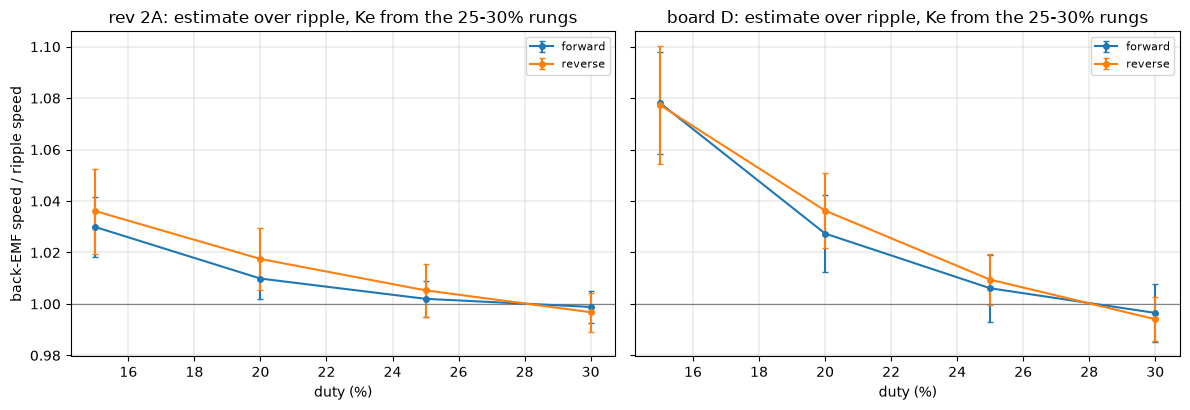

In [4]:
def fits(t, r_ohm, cur):
    out = {}
    for sg in (1, -1):
        g = t[(t.dir == sg) & t.ok & t.v_ok & (t.duty.abs() >= 15)]
        y = g.D * g.V_on - r_ohm * g[cur]
        ke, v0 = np.polyfit(g.f, y, 1)
        top = g.duty.abs() >= 25
        ke_band = (g.f[top] @ y[top]) / (g.f[top] @ g.f[top])
        r = (y / (ke_band * g.f)).groupby(g.duty.abs()).mean()
        out[("fwd" if sg > 0 else "rev")] = {"Ke mV/Hz": ke * 1e3, "V0 mV": v0 * 1e3,
                                             "Ke 25-30% mV/Hz": ke_band * 1e3,
                                             "15% over-read %": (r[15] - 1) * 100, "20% over-read %": (r[20] - 1) * 100}
    return out


rows = {}
for label in SETS:
    t = G[G.set == label]
    for r_ohm in (R_REG.value, FW_R_OHM):
        for cur, zero in (("i_A", "in-drive"), ("i_rest_A", "torque-off")):
            for d, v in fits(t, r_ohm, cur).items():
                rows[(label, d, f"{r_ohm:.2f}", zero)] = v
FIT = pd.DataFrame(rows).T
FIT.index.names = ["board", "dir", "R ohm", "current zero"]
display(FIT.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, label in zip(axes, SETS):
    t = G[(G.set == label) & G.ok & G.v_ok]
    for sg, col in ((1, "tab:blue"), (-1, "tab:orange")):
        g = t[(t.dir == sg) & (t.duty.abs() >= 15)]
        y = g.D * g.V_on - R_REG.value * g.i_A
        top = g.duty.abs() >= 25
        ke_band = (g.f[top] @ y[top]) / (g.f[top] @ g.f[top])
        r = (y / (ke_band * g.f)).groupby(g.duty.abs()).agg(["mean", "std"])
        ax.errorbar(r.index, r["mean"], yerr=r["std"], fmt="o-", ms=4, capsize=2, color=col,
                    label="forward" if sg > 0 else "reverse")
    ax.axhline(1, color="0.5", lw=0.8)
    ax.set_title(f"{label}: estimate over ripple, Ke from the 25-30% rungs")
    ax.set_xlabel("duty (%)")
    ax.grid(True, lw=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("back-EMF speed / ripple speed")
plt.tight_layout()
plt.show()

**What you are looking at.** One row per board, direction, pinned $R$ and current zero. $K_e$ and
$V_0$ from the free line, then the identification-band $K_e$ and what it makes of the 15 and 20%
rungs. The plot draws the registry $R$ with the in-drive zero, error bars the spread over the
five captures.

On the same motor, under the same drive rule and the same model, rev 2A over-reads about a third
of what board D does. With the in-drive zero, $V_0$ is +25 to +49 mV on 2A and +112 to +125 mV
on board D, and the 15% rung reads 2.2 to 3.6% high on 2A against 7.4 to 7.8% on board D. Moving
$R$ from the registry value to the firmware's moves $V_0$ by under 10 mV on either board.

The current zero is the bigger lever on 2A. Read against the torque-off rest instead, the 2A
$V_0$ goes to -16 to +5 mV and the over-read to within 1.2%, because 10 counts of driver supply
current is 45 mV of $R\,i$ at this winding. The in-drive zero is the right one for the firmware,
it is what its tracker learns, so the over-read on 2A is the +25 to +49 mV row. But it is small
enough now that a 9 mA bookkeeping choice is the same size as the effect.

### Do the two terminal chains read the same volts?

Notebook 08 blamed board D's terminal chain. The direct check is a quantity that involves no
current and no drive edge, the open circuit back-EMF in a coast. The session's step block ends
each 30% drive in a 400 ms coast, and with the bridge off the terminal difference is the EMF
itself. Its commutation ripple is in the voltage too, so the coast carries its own speed. The
ridge tracker runs on the terminal difference from the coast's first sample, and each group of
4 whole ripple cycles gives one EMF over frequency point. No current, no $R$, no pot.

In [5]:
def coast_points(d, label, views=("step:60", "step:80", "step:120"), length=1000, per=4, tail=200):
    cp = coupling_prior(d)
    rows = []
    for cap in d.captures("session"):
        for view in views:
            df, meta = session.read(d, cap, view)
            df = df.assign(bias=df[df.seg == 0].current_raw.mean())
            segs = sorted(s for s in df.seg.unique() if s > 0)
            for k in range(len(segs) // 2):
                g, c = df[df.seg == segs[2 * k]], df[df.seg == segs[2 * k + 1]]
                sg = int(np.sign(g.cmd_duty_q15.iloc[0]))
                cyc, n0, ridge = ripple.motor_angle(g, cp, FS, 1.0, f_floor=200.0)
                if cyc is None or n0 > len(g) - tail:
                    continue
                vd = (c.vmotor_a - c.vmotor_b).to_numpy().astype(float) * sg
                # the segment label leads the bridge by a few samples: the coast starts at the
                # turn-off kick, the first sample under half the drive volts
                t0 = int(np.flatnonzero(vd < 0.5 * vd[0])[0])
                x = vd[t0 + 2:t0 + 2 + length][::-1].copy()      # ridge_track walks back from the end
                r = ripple.ridge_track(x, ridge["f"].iloc[-1], FS, fmin=100.0)
                cy = -ripple.demod_cycles(x, r["n"].to_numpy(), r["f"].to_numpy(), FS)[::-1]
                x = x[::-1]
                edges = np.flatnonzero(np.diff(np.floor(cy - cy[0])) > 0) + 1
                for j in range(0, len(edges) - per, per):
                    a, b = edges[j], edges[j + per]
                    rows.append(dict(set=label, cap=cap, dir=sg, f=per / ((b - a) * DT),
                                     e=x[a:b].mean() * d.board.v_term_per_count))
    return pd.DataFrame(rows)


C = pd.concat([coast_points(d, k) for k, d in SETS.items()], ignore_index=True)
C["Ke"] = C.e / C.f * 1e3
C["dir"] = np.where(C.dir > 0, "fwd", "rev")
C["band"] = pd.cut(C.f, [500, 900, 1100, 1300])
coast = C.groupby(["set", "dir", "band"], observed=True).Ke.agg(["mean", "std", "size"]).unstack("band")
display(coast.round(4))
drive = FIT.xs((f"{R_REG.value:.2f}", "in-drive"), level=("R ohm", "current zero"))["Ke 25-30% mV/Hz"]
cmp = pd.DataFrame({"coast Ke, 700-1300 Hz": C[C.f.between(700, 1300)].groupby(["set", "dir"]).Ke.mean()})
cmp["drive Ke, 25-30%"] = drive.reindex(cmp.index).values
cmp["drive over coast"] = cmp.iloc[:, 1] / cmp.iloc[:, 0]
display(cmp.round(4))

mean                                 std                                size                         
band        (500, 900] (900, 1100] (1100, 1300] (500, 900] (900, 1100] (1100, 1300] (500, 900] (900, 1100] (1100, 1300]
set     dir                                                                                                            
board D fwd     1.2137      1.2100       1.2100     0.0084      0.0064       0.0092         42          54           60
        rev     1.2405      1.2336       1.2289     0.0087      0.0069       0.0080         38          59           67
rev 2A  fwd     1.2420      1.2402       1.2345     0.0057      0.0076       0.0196         66          57           28
        rev     1.2424      1.2398       1.2278     0.0110      0.0078       0.0184         66          61           32

coast Ke, 700-1300 Hz  drive Ke, 25-30%  drive over coast
set     dir                                                           
board D fwd                 1.2110            1.3629            1.1255
        rev                 1.2333            1.4058            1.1399
rev 2A  fwd                 1.2393            1.3281            1.0717
        rev                 1.2380            1.3597            1.0983

**What you are looking at.** The coast $K_e$, EMF over ripple frequency in mV per ripple Hz, in
speed bands, and below it the coast against the drive $K_e$ of the section above.

The two boards' coast readings agree to 0.4% reverse and 2.3% forward, 1.238 and 1.239 mV per
Hz on 2A against 1.233 and 1.211 on board D. So board D's terminal chain reads the open circuit
EMF about as well as 2A's does, the forward tap a couple of percent low. That is far too small
to be the 7.5% low duty over-read, and it points the wrong way for it. A tap that reads low
under-reads, it does not over-read.

The drive $K_e$ sits 7 to 14% over the coast one on both boards. A brushed motor under load
needs more volts per hertz than it generates free, the brushes and the coil being commutated
under current take their share, so the drive constant is the one the firmware model wants and
the coast one is only a cross-check of the chain.

## 4. Two candidates

**(a) The drive pulse is shorter than commanded.** The firmware takes the period mean as
$D\,v_{on}$, which assumes the terminal sits at $v_{on}$ for the whole commanded window. The
DRV8212P turns on late by its dead time plus propagation and rise, and turns off a little late,
so the real ON pulse is short by a fixed number of timer ticks. The crest sample cannot see an
edge, so the model over-reads the volt-seconds by $v_{on} \cdot \Delta t / (2\,\mathrm{ARR})$,
a constant in volts at a fixed rail. The shortfall counts against the whole 2400-tick period,
not the 1200-tick half, because the ON pulse is centered on the crest and loses its edges out of
the full width. On 2A board #1 the current pulse on the resistor grid is 30 ticks short at half height
(notebook 10 sec 8.1), and the identification burst fit on the MG90 says 20 to 23. A bench
analysis of the MG90's stall ladder and bursts, recordings that are not in a dataset yet, adds
the slow fall the motor's own terminal capacitance gives at small currents. Net, the pulse
comes out 10 to 15 ticks short at about 0.1 A and 20 to 25 at 0.2 A and up.

**(b) The OFF window is not at zero volts.** The estimator drafted for averaging terminal taps
weights the crest and trough terminal differences by their own ticks,
$v_{mean} = (t\,v_{crest} + (\mathrm{ARR} - t)\,v_{trough})/\mathrm{ARR}$, with the OFF term
dropped when the OFF half is under the voltage floor. On today's 100 pF taps the trough sample
reads the slow decay brake level, the two low side channels carrying the winding current,
$-2 R_{ds}\,i$. So on this board (b) is notebook 08's brake drop term. The trough terminals are
converted every tick but no telemetry bit carries them, so the term is projected here from
notebook 08's brake measurement of the bridge, $2 R_{ds}$ = 0.23 ohm, bracket 0.12 to 0.34.
The identification burst on 2A puts the chopping terminal at -24 mV through the OFF phase at
its 0.2 to 0.25 A, which is the same size.

On 100 pF taps (b) cannot see the edges at all, both of its samples sit mid-phase. So the two
candidates do not overlap, and they can be added.

Each variant below changes the period mean, refits $K_e$ through the origin on the 25 and 30%
rungs the way an identification band would, and scores 10 to 20% against it. $V_0$ is what is
left of the free line's intercept.

In [6]:
TWO_RDS = (0.23, 0.12, 0.34)        # ohm, nb08's brake measurement on board D's bridge: value, lo, hi
DT_TICKS = (10, 15, 20, 25, 30)     # ON pulse shortfall in timer ticks of the full 2 x ARR period


def v_mean(t, dead=0.0, two_rds=0.0):
    # (a): the pulse is `dead` ticks short of 2 x drive_ticks, so the volt-seconds are (D - dead/(2 ARR)) V_on.
    # (b): the OFF window weighted by its own ticks at the brake level -2 Rds i, dropped when the
    #      OFF half is under the voltage floor, the way study 28 gates it.
    off = np.where(ARR - t.ticks >= V_FLOOR, (1 - t.D) * two_rds * t.i_A, 0.0)
    return (t.D - dead / (2 * ARR)) * t.V_on - off


def score(t, dead=0.0, two_rds=0.0, r_ohm=R_REG.value):
    out = {}
    for sg in (1, -1):
        g = t[(t.dir == sg) & t.ok & t.v_ok]
        y = v_mean(g, dead, two_rds) - r_ohm * g.i_A
        m = g.duty.abs() >= 15
        ke, v0 = np.polyfit(g.f[m], y[m], 1)
        top = g.duty.abs() >= 25
        ke_band = (g.f[top] @ y[top]) / (g.f[top] @ g.f[top])
        r = (y / (ke_band * g.f)).groupby(g.duty.abs()).mean()
        d = "fwd" if sg > 0 else "rev"
        out[f"{d} V0 mV"] = v0 * 1e3
        for k in (10, 15, 20):
            if k in r.index:
                out[f"{d} {k}%"] = (r[k] - 1) * 100
    return out


variants = {"firmware as it stands": {}}
for dt in DT_TICKS:
    variants[f"(a) pulse {dt} ticks short"] = {"dead": dt}
variants[f"(b) OFF window, 2 Rds {TWO_RDS[0]} ohm"] = {"two_rds": TWO_RDS[0]}
variants[f"(b) OFF window, 2 Rds {TWO_RDS[2]} ohm"] = {"two_rds": TWO_RDS[2]}
variants[f"(a) 12 ticks + (b) {TWO_RDS[0]} ohm"] = {"dead": 12, "two_rds": TWO_RDS[0]}

for label in SETS:
    t = G[G.set == label]
    S = pd.DataFrame({k: score(t, **v) for k, v in variants.items()}).T
    print(f"{label}: V0 left over, and the over-read in % against the 25-30% Ke (R {R_REG.value} ohm, in-drive zero)")
    display(S.round(1))

# The shortfall each board's V0 asks for, alone and beside (b).
rows = []
for label in SETS:
    t = G[G.set == label]
    v_on = t[t.ok & t.v_ok].V_on.mean()
    base = score(t)
    with_b = score(t, two_rds=TWO_RDS[0])
    for d in ("fwd", "rev"):
        rows.append({"board": label, "dir": d, "V_on": v_on,
                     "ticks, (a) alone": base[f"{d} V0 mV"] / 1e3 / v_on * 2 * ARR,
                     "ticks, (a) beside (b)": with_b[f"{d} V0 mV"] / 1e3 / v_on * 2 * ARR})
display(pd.DataFrame(rows).set_index(["board", "dir"]).round(1))

rev 2A: V0 left over, and the over-read in % against the 25-30% Ke (R 4.89 ohm, in-drive zero)


,fwd V0 mV,fwd 10%,fwd 15%,fwd 20%,rev V0 mV,rev 15%,rev 20%
firmware as it stands,34.3,6.4,3.0,1.0,48.8,3.6,1.7
(a) pulse 10 ticks short,3.5,-0.1,0.5,-0.0,17.9,1.2,0.8
(a) pulse 15 ticks short,-12.0,-3.5,-0.8,-0.6,2.5,-0.1,0.3
(a) pulse 20 ticks short,-27.4,-6.9,-2.2,-1.1,-12.9,-1.4,-0.2
(a) pulse 25 ticks short,-42.8,-10.4,-3.5,-1.7,-28.4,-2.7,-0.8
(a) pulse 30 ticks short,-58.2,-14.0,-4.9,-2.3,-43.8,-4.0,-1.3
"(b) OFF window, 2 Rds 0.23 ohm",18.0,3.4,1.7,0.4,33.9,2.4,1.3
"(b) OFF window, 2 Rds 0.34 ohm",10.2,1.9,1.1,0.1,26.8,1.9,1.1
(a) 12 ticks + (b) 0.23 ohm,-19.0,-4.6,-1.4,-0.9,-3.1,-0.6,0.1


board D: V0 left over, and the over-read in % against the 25-30% Ke (R 4.89 ohm, in-drive zero)


,fwd V0 mV,fwd 10%,fwd 15%,fwd 20%,rev V0 mV,rev 15%,rev 20%
firmware as it stands,117.7,20.4,7.8,2.7,125.1,7.7,3.6
(a) pulse 10 ticks short,85.2,15.5,5.8,1.9,92.6,5.7,2.8
(a) pulse 15 ticks short,69.0,13.0,4.8,1.5,76.3,4.7,2.4
(a) pulse 20 ticks short,52.7,10.5,3.8,1.1,60.1,3.6,2.0
(a) pulse 25 ticks short,36.5,7.9,2.7,0.6,43.8,2.6,1.5
(a) pulse 30 ticks short,20.2,5.2,1.7,0.2,27.6,1.5,1.1
"(b) OFF window, 2 Rds 0.23 ohm",107.8,19.2,7.2,2.5,114.7,7.1,3.4
"(b) OFF window, 2 Rds 0.34 ohm",103.0,18.6,7.0,2.3,109.8,6.8,3.3
(a) 12 ticks + (b) 0.23 ohm,68.8,13.3,4.8,1.5,75.8,4.6,2.4


V_on  ticks, (a) alone  ticks, (a) beside (b)
board   dir                                               
rev 2A  fwd   7.4              11.1                    5.8
        rev   7.4              15.8                   11.0
board D fwd   7.8              36.3                   33.2
        rev   7.8              38.5                   35.4

**What you are looking at.** For each board, each variant's leftover $V_0$ and its over-read at
10, 15 and 20% in percent, forward and reverse. The 10% reverse rung has no honest volts, so it
has no column. The last table is how many ticks of shortfall each board's $V_0$ asks for, with
(a) alone and with (a) beside (b) at 0.23 ohm.

**On 2A, (a) explains it.** A pulse 11 ticks short forward and 16 reverse zeroes $V_0$, 6 and 11
with (b) beside it. At 10 ticks every 2A rung from 10 to 20% reads within 1.2% of the 25 to 30%
$K_e$. At 15 ticks the 15 and 20% rungs are within 0.8% and the 10% forward rung goes 3.5% low.
That is the 10 to 15 ticks measured for this motor at its free running current, 72 to 100 mA
here. The 20 to 30 ticks of the resistor grid over-correct, they leave the 15% rung 1.4 to 4.9%
low and the 10% rung 7 to 14% low. The 5 tick split between directions is about what (b) moves
it by, so the data pins the shortfall to 6 to 16 ticks and no closer.

**(b) is real and small.** At 0.23 ohm it takes 16 mV off $V_0$ and leaves the 15% rung 1.7 to 2.4%
high. It is the right sign and it belongs in any model that claims the period mean, but on its
own it is a third to a half of the effect.

**What remains on 2A** with (a) at 10 ticks is inside 1.2% at every rung from 10 to 20%, both
ways, and the 25 and 30% rungs sit on the fitted $K_e$ by construction. That is the size of the
capture to capture spread in section 2, so this data cannot resolve anything smaller.

**Board D does not close the same way.** Its $V_0$ asks for a pulse 36 to 39 ticks short, 33 to 35
beside (b). Its currents are lower than 2A's, 44 to 69 mA, so by the same bench analysis its shortfall
should be smaller, not three times larger. Whatever board D adds on top is about 70 to 90 mV that
2A does not have, and section 3's coast check says it is not the scale of board D's terminal
chain. It is something that only happens with the bridge switching on board D. Board D is the
temporary rig rev 2A replaces, so this stays a note and not a task.

## 5. Does it explain verify?

The identification run after this session ended with `osc ident verify`. Its velocity legs held
600 and 1200 linearized counts per second each way in Velocity mode, and the pot slope over each
leg came out 3.4 and 4.0% under the goal at 600, 3.9 and 4.7% under at 1200, forward and reverse.
A velocity PI with an integrator settles where its feedback reads the goal, so a feedback that
reads 4% fast would make a shaft that runs 4% slow. The model's over-read is the right sign for
that. Two things decide whether it is the cause.

The first is whether the loop was even on the back-EMF. `OmegaSwitch` hands the loop the
back-EMF boxcar only after 4 clean halves in a row, and a half is clean only if every tick in
it had a drive window of at least the voltage floor, 160 ticks on this build. The table below
places each verify speed on the ripple-scored grid line, in duty and in drive ticks.

The second is the shape. If the loop had been on the back-EMF, the model's line through the 15 to
30% rungs, with the firmware's own $R$ and $K_e$, says what it would have read at each goal.

In [7]:
VERIFY = {600: (3.4, 4.0), 1200: (3.9, 4.7)}      # verify velocity, % low: forward, reverse (identification run log)
A = G[(G.set == "rev 2A") & G.ok].copy()
A["w"] = A.f / CPC
rows = []
for sg in (1, -1):
    g = A[(A.dir == sg) & (A.duty.abs() >= 15)]
    slope, icpt = np.polyfit(g.D * 100, g.w, 1)           # linearized c/s per % duty, from ripple-scored rungs
    y = g.D * g.vd - FW_R_VPC * g.i
    ke, v0 = np.polyfit(g.w, y, 1)                        # vcounts per c/s and vcounts, the model's own line
    for w_goal, err in VERIFY.items():
        duty = (w_goal - icpt) / slope
        ticks = duty / 100 * ARR
        rows.append({"dir": "fwd" if sg > 0 else "rev", "goal c/s": w_goal,
                     "duty %": duty, "drive ticks": ticks, "voltage window valid": ticks >= V_FLOOR,
                     "if on back-EMF, est/true": (ke * w_goal + v0) / (FW_KE_VPC * w_goal),
                     "verify read, % low": err[0 if sg > 0 else 1]})
V = pd.DataFrame(rows).set_index(["dir", "goal c/s"])
display(V.round(3))
t10 = A[(A.duty == 10) & A.v_ok]
r10 = ((t10.D * t10.vd - FW_R_VPC * t10.i) / FW_KE_VPC / t10.w)
print(f"10% forward rung, measured: {t10.w.mean():.0f} c/s, {t10.ticks.mean():.0f} drive ticks, "
      f"firmware est/true {r10.mean():.3f} (captures {r10.min():.3f} .. {r10.max():.3f})")

duty %  drive ticks  voltage window valid  if on back-EMF, est/true  verify read, % low
dir goal c/s                                                                                         
fwd 600        8.236       98.832                 False                     1.066                 3.4
    1200      11.312      135.745                 False                     1.010                 3.9
rev 600        7.983       95.802                 False                     1.150                 4.0
    1200      11.162      133.945                 False                     1.059                 4.7

10% forward rung, measured: 1024 c/s, 120 drive ticks, firmware est/true 1.013 (captures 0.968 .. 1.032)


**What you are looking at.** One row per verify leg. The duty and drive ticks that speed takes on
this servo at this rail, from a line through the ripple-scored 15 to 30% rungs, whether that
window clears the voltage floor, what the back-EMF would have read over the truth there, and
what verify measured. Below it, the 10% forward rung measured directly, about the speed of the
1200 legs.

Every verify leg runs at 8 to 11% duty, 96 to 136 ticks, under the 160 tick floor. The back-EMF
boxcar is void on every half, so the loop ran all four legs on the pot observer, and the
back-EMF never touched them. The observer works in the same linearized counts verify fits its
slope in, and with its disturbance state it tracks a steady ramp with no error, so this is a
place where verify should read close to zero.

The shape rules the model out as well. Had the loop been on the back-EMF, it would read 6.6 and
15% fast at 600 and 1.0 and 5.9% fast at 1200, the error falling with speed as a constant
$V_0$ does. Verify's error grows a little with speed, 3.4 to 3.9% forward and 4.0 to 4.7%
reverse. At the 10% forward rung, measured rather than extrapolated, the firmware reads 1.3%
fast. So neither candidate has anything to say about verify, and its 4% is open.

## What this says for the firmware

Nothing has to change for 2A. The firmware model with the constants the servo carries reads
within 4.4% of the ripple at every 2A rung from 10 to 30%, and the low duty over-read notebook 08
measured on board D is down to about 3% at 15% on the same motor.

If the period mean is ever tightened, the data supports one change, and it is (a). Take a fixed
edge loss off the drive window before the multiply, `(drive_ticks - E) * vdiff`, with E about 5
drive ticks (10 ticks of full width), as board data next to the floors. It is a subtraction, no
divide and no new branch. Two things hold it back. The shortfall moves with the current, 10 to 15
ticks at 0.1 A against 20 to 25 at 0.2 A and up, so a single E is right for a free running shaft
and slightly short under load. And the identification ladder fits $K_e$ with the same $D\,v_{on}$
model, so E has to land in `ident` in the same change or $K_e$ absorbs the difference. Term (b) is
worth carrying only together with that, from the trough terminals the scan already converts.
Averaging terminal taps, a 100 nF cap in place of each 100 pF, would measure both terms in
hardware instead and make E unnecessary.

## Caveats

- One servo, two sessions two days apart. The MG90 draws 45 to 55% more current on 2A than on
  board D at the same duty and runs 11 to 17% slower. The comparison is per board, but anything
  that moves with current, the shortfall included, moved with it.
- $K_e$ and $V_0$ trade off over a 2.5 to 1 speed range. The 10% forward rung is scored against
  the 15 to 30% line rather than fitted into it, and it lands within a point of where that line
  puts it, but the tick counts above are good to a few ticks, not to one.
- The current zero is worth 45 mV on 2A. The in-drive zero is the firmware's and the right one,
  but a 9 mA question of bookkeeping is now the same size as the effect.
- $2 R_{ds}$ for (b) is board D's brake measurement. No 2A recording streams the trough
  terminals.

## Open

- **Verify's 4%.** The loop ran on the pot observer, and both the observer and verify work in the
  0xdc96 linearized counts. One candidate the session cannot test is the time base. The ident
  tool notes that every polled read stalls the kernel for a few ticks. If those stalls drop
  kernel ticks, the observer's counts per kernel second read high against the host's clock, and
  the loop settles slow by the fraction of ticks lost. A Velocity-mode leg with `omega_hat_src`
  and `sample_tick` logged, at the 4 ms poll and with polling off, would settle it.
- **Board D's extra 70 to 90 mV.** Present only with the bridge switching, absent from the coast.
  Board D is the temporary rig, so this stays a note.
- **The shortfall against current.** A free shaft only spans 70 to 100 mA. A stalled ladder with
  a DC meter in series with the motor would give the ON pulse at known currents and pin E.